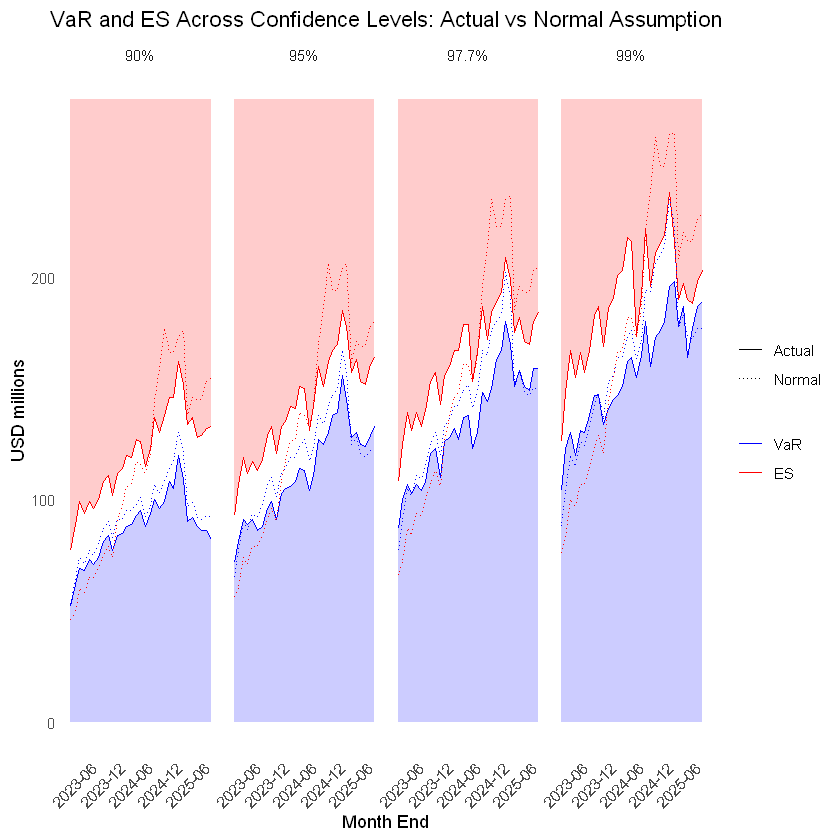

In [40]:
library(readxl)
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)

# Read and preprocess data
data <- read_excel("VaR_Metrics.xlsx", sheet = "Sheet1") %>%
  mutate(Month_End = as.Date(Month_End)) %>%
  filter(Month_End >= as.Date("2023-01-01")) %>%
  select(Month_End,
         VaR90, ES90, NormVaR90, NormES90,
         VaR95, ES95, NormVaR95, NormES95,
         VaR97.7, ES97.7, NormVaR97.7, NormES97.7,
         VaR99, ES99, NormVaR99, NormES99) %>%
  pivot_longer(-Month_End, names_to = "Metric", values_to = "USD_Millions") %>%
  mutate(
    Confidence_Level = case_when(
      grepl("90", Metric) ~ "90%",
      grepl("95", Metric) ~ "95%",
      grepl("97.7", Metric) ~ "97.7%",
      grepl("99", Metric) ~ "99%"
    ),
    Measure = if_else(grepl("ES", Metric), "ES", "VaR"),
    Assumption = if_else(grepl("Norm", Metric), "Normal", "Actual"),
    Confidence_Level = factor(Confidence_Level, levels = c("90%", "95%", "97.7%", "99%")),
    Measure = factor(Measure, levels = c("VaR", "ES")),
    Assumption = factor(Assumption, levels = c("Actual", "Normal"))
  )

# Extract actual VaR and ES data for ribbons, set ribbon_top to 280 everywhere
actual_data <- filter(data, Assumption == "Actual") %>%
  mutate(ribbon_top = 280)

# Colors and linetypes settings
colors <- c("ES" = "red", "VaR" = "blue")
linetypes <- c("Actual" = "solid", "Normal" = "dotted")

ggplot(data, aes(x = Month_End)) +
  # Ribbon below actual VaR (blue area)
  geom_ribbon(
    data = filter(actual_data, Measure == "VaR"),
    aes(ymin = 0, ymax = USD_Millions, group = Confidence_Level),
    fill = "blue", alpha = 0.2
  ) +
  # Ribbon above actual ES (red area, top at 280)
  geom_ribbon(
    data = filter(actual_data, Measure == "ES"),
    aes(ymin = USD_Millions, ymax = ribbon_top, group = Confidence_Level),
    fill = "red", alpha = 0.2
  ) +
  # Lines
  geom_line(
    aes(y = USD_Millions, color = Measure, linetype = Assumption, group = interaction(Measure, Assumption, Confidence_Level)),
    size = 0.5
  ) +
  facet_wrap(~Confidence_Level, nrow = 1, scales = "fixed") +
  scale_color_manual(values = colors) +
  scale_linetype_manual(values = linetypes) +
  scale_x_date(
    name = "Month End",
    breaks = scales::date_breaks("6 months"),
    labels = scales::date_format("%Y-%m")
  ) +
  scale_y_continuous(
    name = "USD millions",
    labels = scales::comma,
    limits = c(0, 280)   # y axis from 0 to 280
  ) +
  ggtitle("VaR and ES Across Confidence Levels: Actual vs Normal Assumption") +
  theme_minimal() +
  theme(
    legend.title = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(hjust = 0.5),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  )


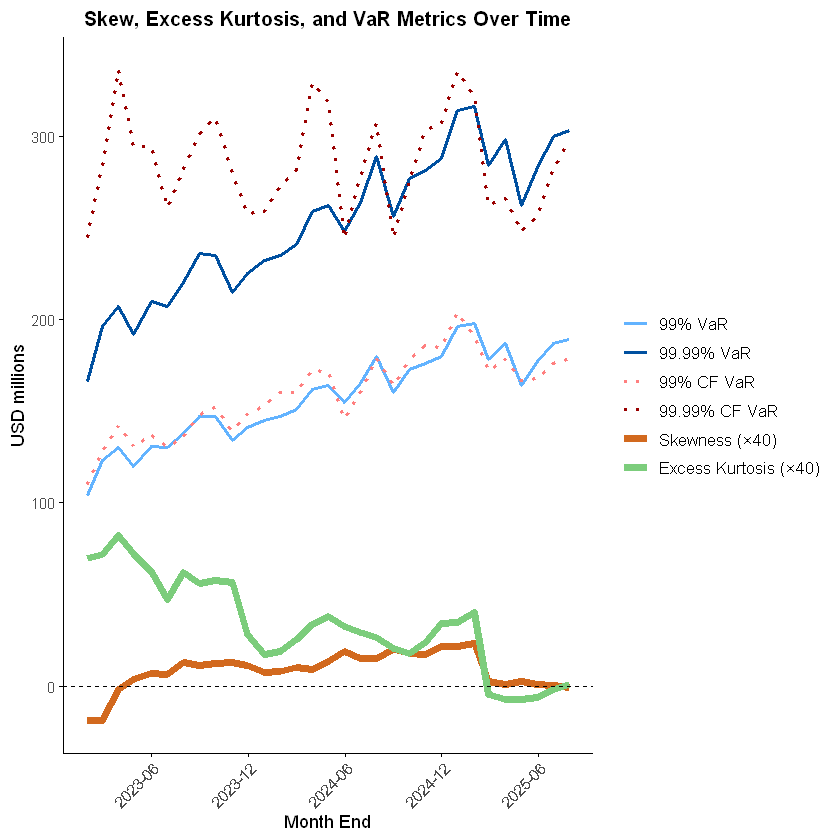

In [39]:
library(readxl)
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)

# Prepare data and set legend order
data <- read_excel("VaR_Metrics.xlsx", sheet = "Sheet1") %>%
  mutate(Month_End = as.Date(Month_End)) %>%
  filter(Month_End >= as.Date("2023-01-01")) %>%
  select(Month_End, Skew, `Excess K`, VaR99, CFVAR99, VaR99.99_normal_scaled, CFVAR99.99) %>%
  mutate(Skew = Skew * 40, `Excess K` = `Excess K` * 40) %>%
  pivot_longer(-Month_End, names_to = "Raw", values_to = "Value") %>%
  mutate(
    Label = case_when(
      Raw == "Skew" ~ "Skewness (×40)",
      Raw == "Excess K" ~ "Excess Kurtosis (×40)",
      Raw == "VaR99" ~ "99% VaR",
      Raw == "CFVAR99" ~ "99% CF VaR",
      Raw == "VaR99.99_normal_scaled" ~ "99.99% VaR",
      Raw == "CFVAR99.99" ~ "99.99% CF VaR"
    ),
    LineColor = case_when(
      Label == "99% VaR" ~ "#62B3FF",          # light blue
      Label == "99.99% VaR" ~ "#0050A0",       # dark blue
      Label == "99% CF VaR" ~ "#FF7F7F",       # light red
      Label == "99.99% CF VaR" ~ "#990000",    # dark red
      Label == "Skewness (×40)" ~ "#D2691E",          # light brown (lighter than 'brown')
      Label == "Excess Kurtosis (×40)" ~ "#7CCD7C"    # light green
    ),
    LineType = case_when(
      Label %in% c("99% VaR", "99.99% VaR", "Skewness (×40)", "Excess Kurtosis (×40)") ~ "solid",
      TRUE ~ "dotted"
    ),
    Size = case_when(
      Label %in% c("Skewness (×40)", "Excess Kurtosis (×40)") ~ 2,
      TRUE ~ 1
    ),
    Label = factor(Label, levels = c(
      "99% VaR",
      "99.99% VaR",
      "99% CF VaR",
      "99.99% CF VaR",
      "Skewness (×40)",
      "Excess Kurtosis (×40)"
    ))
  )

ggplot(data, aes(x = Month_End, y = Value, color = Label, linetype = Label, size = Label, group = Label)) +
  geom_line(show.legend = TRUE) +
  geom_hline(yintercept = 0, color = "black", linewidth = 0.5, linetype = "dashed") +
  scale_color_manual(
    values = c(
      "99% VaR" = "#62B3FF",
      "99.99% VaR" = "#0050A0",
      "99% CF VaR" = "#FF7F7F",
      "99.99% CF VaR" = "#990000",
      "Skewness (×40)" = "#D2691E",          # lighter brown
      "Excess Kurtosis (×40)" = "#7CCD7C"    # lighter green
    ),
    breaks = levels(data$Label),
    name = NULL
  ) +
  scale_linetype_manual(
    values = c(
      "99% VaR" = "solid",
      "99.99% VaR" = "solid",
      "99% CF VaR" = "dotted",
      "99.99% CF VaR" = "dotted",
      "Skewness (×40)" = "solid",
      "Excess Kurtosis (×40)" = "solid"
    ),
    breaks = levels(data$Label),
    name = NULL
  ) +
  scale_size_manual(
    values = c(
      "99% VaR" = 1,
      "99.99% VaR" = 1,
      "99% CF VaR" = 1,
      "99.99% CF VaR" = 1,
      "Skewness (×40)" = 2,
      "Excess Kurtosis (×40)" = 2
    ),
    breaks = levels(data$Label),
    name = NULL
  ) +
  scale_x_date(
    name = "Month End",
    breaks = date_breaks("6 months"),
    labels = date_format("%Y-%m")
  ) +
  scale_y_continuous(name = "USD millions", labels = comma) +
  ggtitle("Skew, Excess Kurtosis, and VaR Metrics Over Time") +
  theme_minimal() +
  theme(
    legend.position = "right",
    legend.box = "vertical",
    legend.text = element_text(size = 10),
    legend.title = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    plot.title = element_text(hjust = 0.5, size = 12, face = "bold"),
    axis.line = element_line(color = "black", linewidth = 0.4),
    axis.ticks = element_line(color = "black", linewidth = 0.4)
  )
